# Hybrid TPU + GDDR6-AiM Evaluation

This notebook evaluates an LLM workload on a hybrid architecture that combines a
TPU-style systolic array with a GDDR6-AiM (Accelerator-in-Memory) processing-in-memory
system. A `Fork` in the architecture lets the mapper assign each einsum to whichever
compute path is more efficient:

- **TPU path**: 128x128 systolic array with 128 MB global buffer (compute-bound ops)
- **AiM path**: 512 independent PUs with 32 GB/s per-bank DRAM (memory-bound ops)

## Setup

In [5]:
from pathlib import Path
import accelforge as af

examples_dir = Path("../examples")

HYBRID_ARCH = examples_dir / "arches" / "tpu_aim_hybrid.yaml"
WORKLOAD = examples_dir / "workloads" / "gpt3_small_hybrid.yaml"

BATCH_SIZE = 1
N_TOKENS = 1  # Decode phase: 1 token at a time

spec = af.Spec.from_yaml(
    HYBRID_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

## Architecture

The hybrid architecture uses a `Fork` to split into two compute paths from shared
HBM main memory. The TPU path has a deep memory hierarchy (GlobalBuffer, LocalBuffer,
Register) feeding a 128x128 systolic array. The AiM path has 512 independent
processing units, each with its own 32 GB/s DRAM bank and 2 KB global buffer.

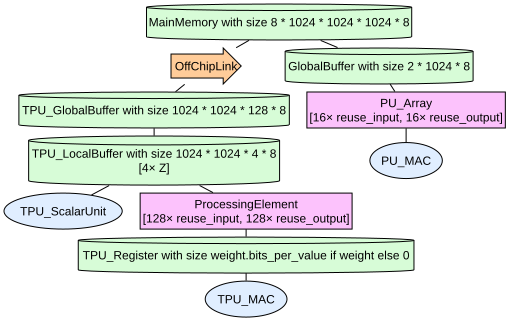

In [6]:
spec.arch

## Workload

GPT-3-like transformer with small ranks for fast mapper evaluation. Includes QKV
projections, attention (QK, softmax, AV), output projection, and FFN layers.
Rank ratios match GPT-3 6.7B scaled down by 64x.

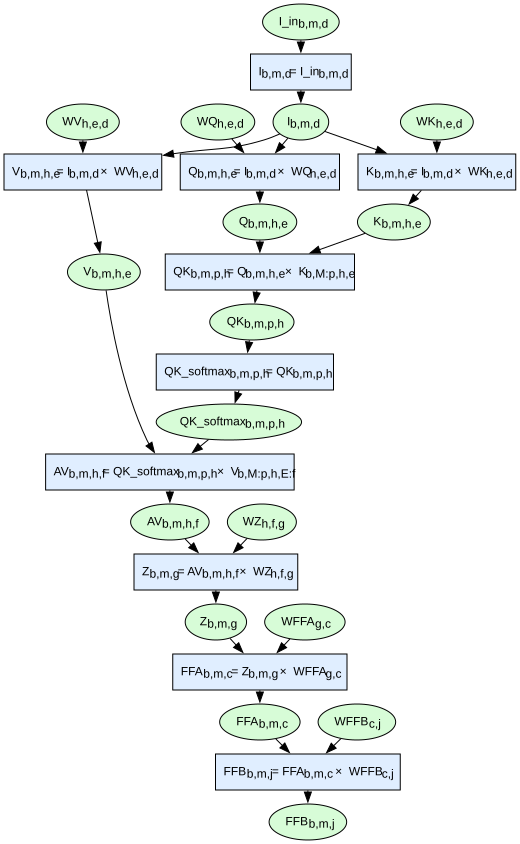

In [7]:
spec.workload

## Map Workload to Architecture

We map the full workload in a single call. The mapper jointly optimizes across all
einsums and automatically assigns each to the TPU or AiM path through the Fork.

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:05<00:00,  1.92it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 127.79it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s], ?it/s], ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 515.90it/s]/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]]

Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I_in in OffChipLink] [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  [I in OffChipLink] [I_in in OffChipLink] S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [WV in OffChipLink] [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h 

Compressing pmappings: 100%|██████████| 10/10 [00:03<00:00,  2.75it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 548.60it/s]


...

Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 472.67it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 2313 -> 2313 (100.00% kept) pmappings


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 83.47it/s]


Dirty joining mapping(s) valid & optimal! Returning...


Evaluating chosen mappings in detail: 100%|██████████| 13/13 [00:08<00:00,  1.54it/s]


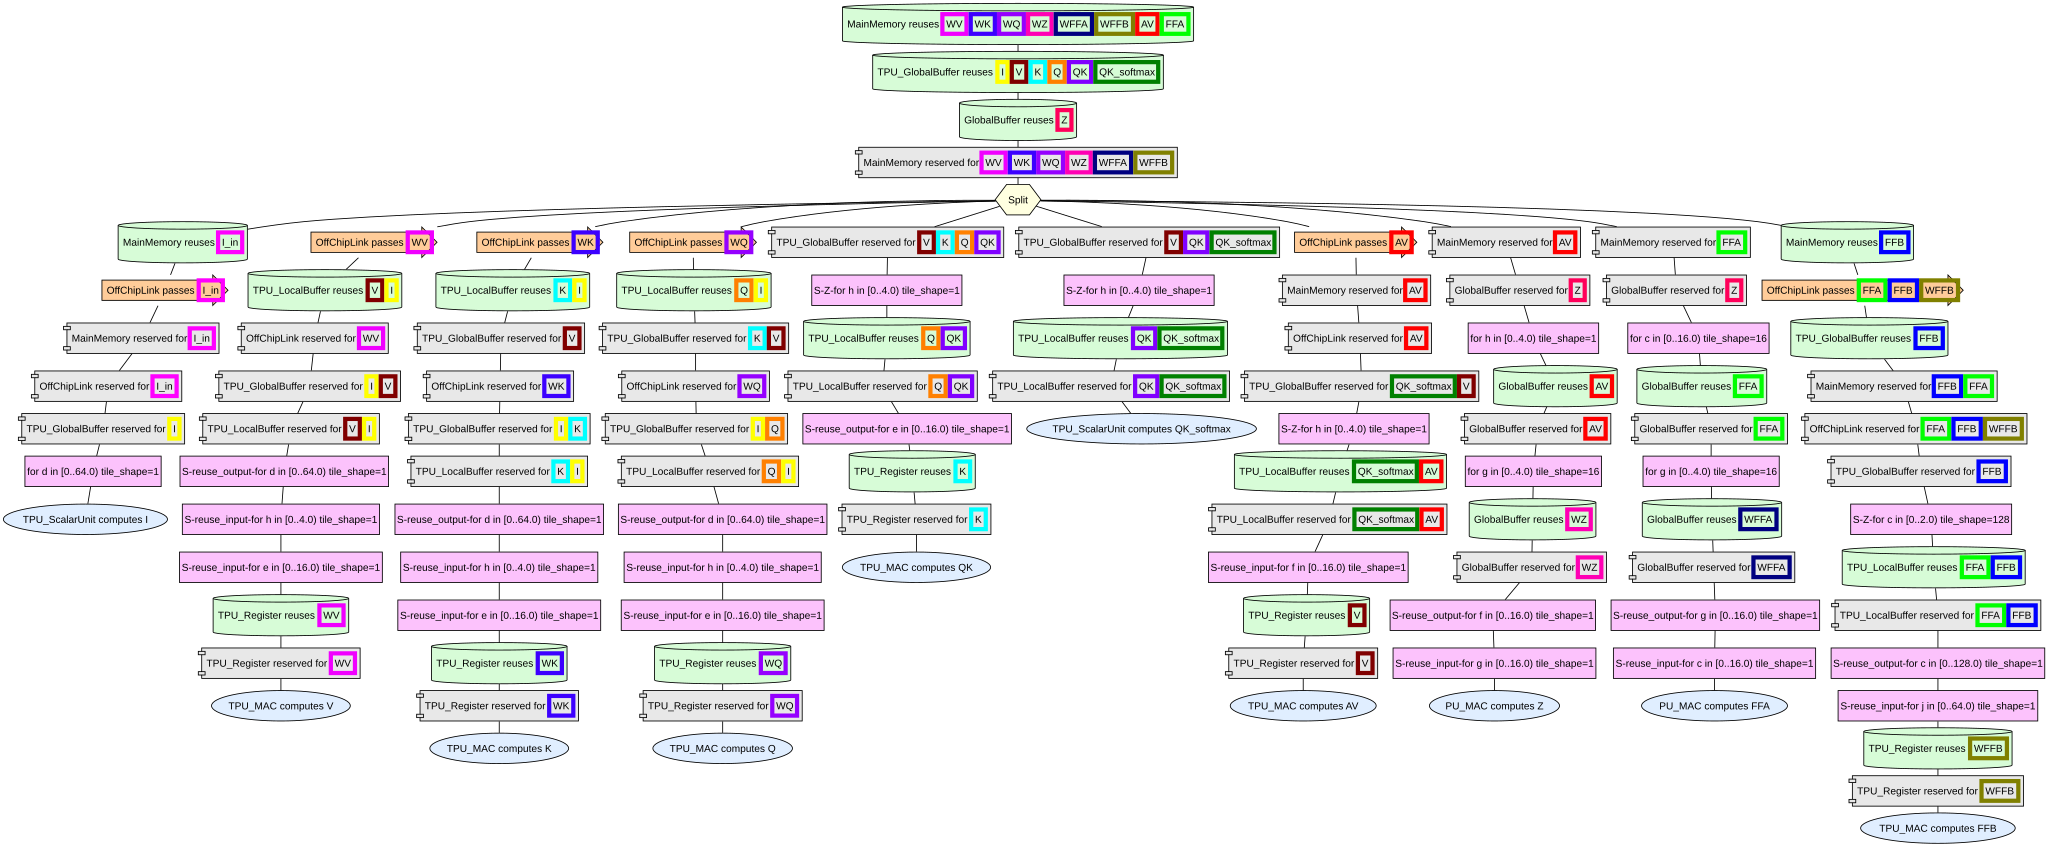

In [8]:
spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
mapping = spec.map_workload_to_arch()
mapping[0].render()

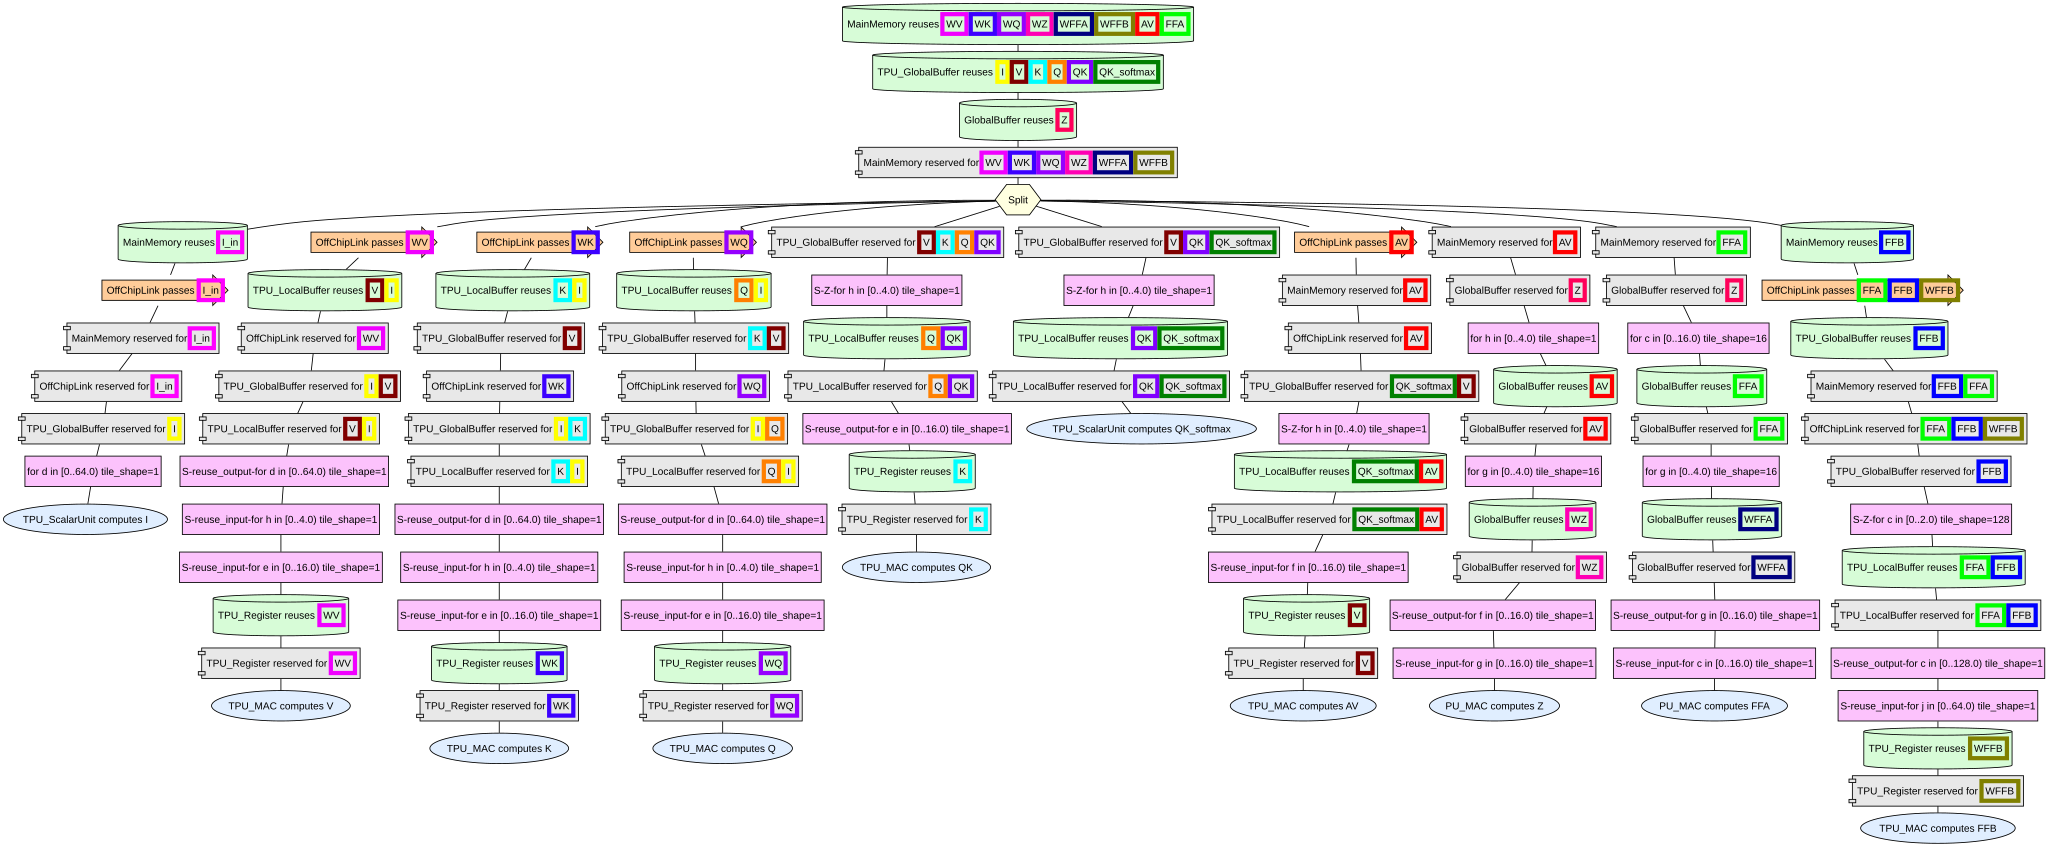

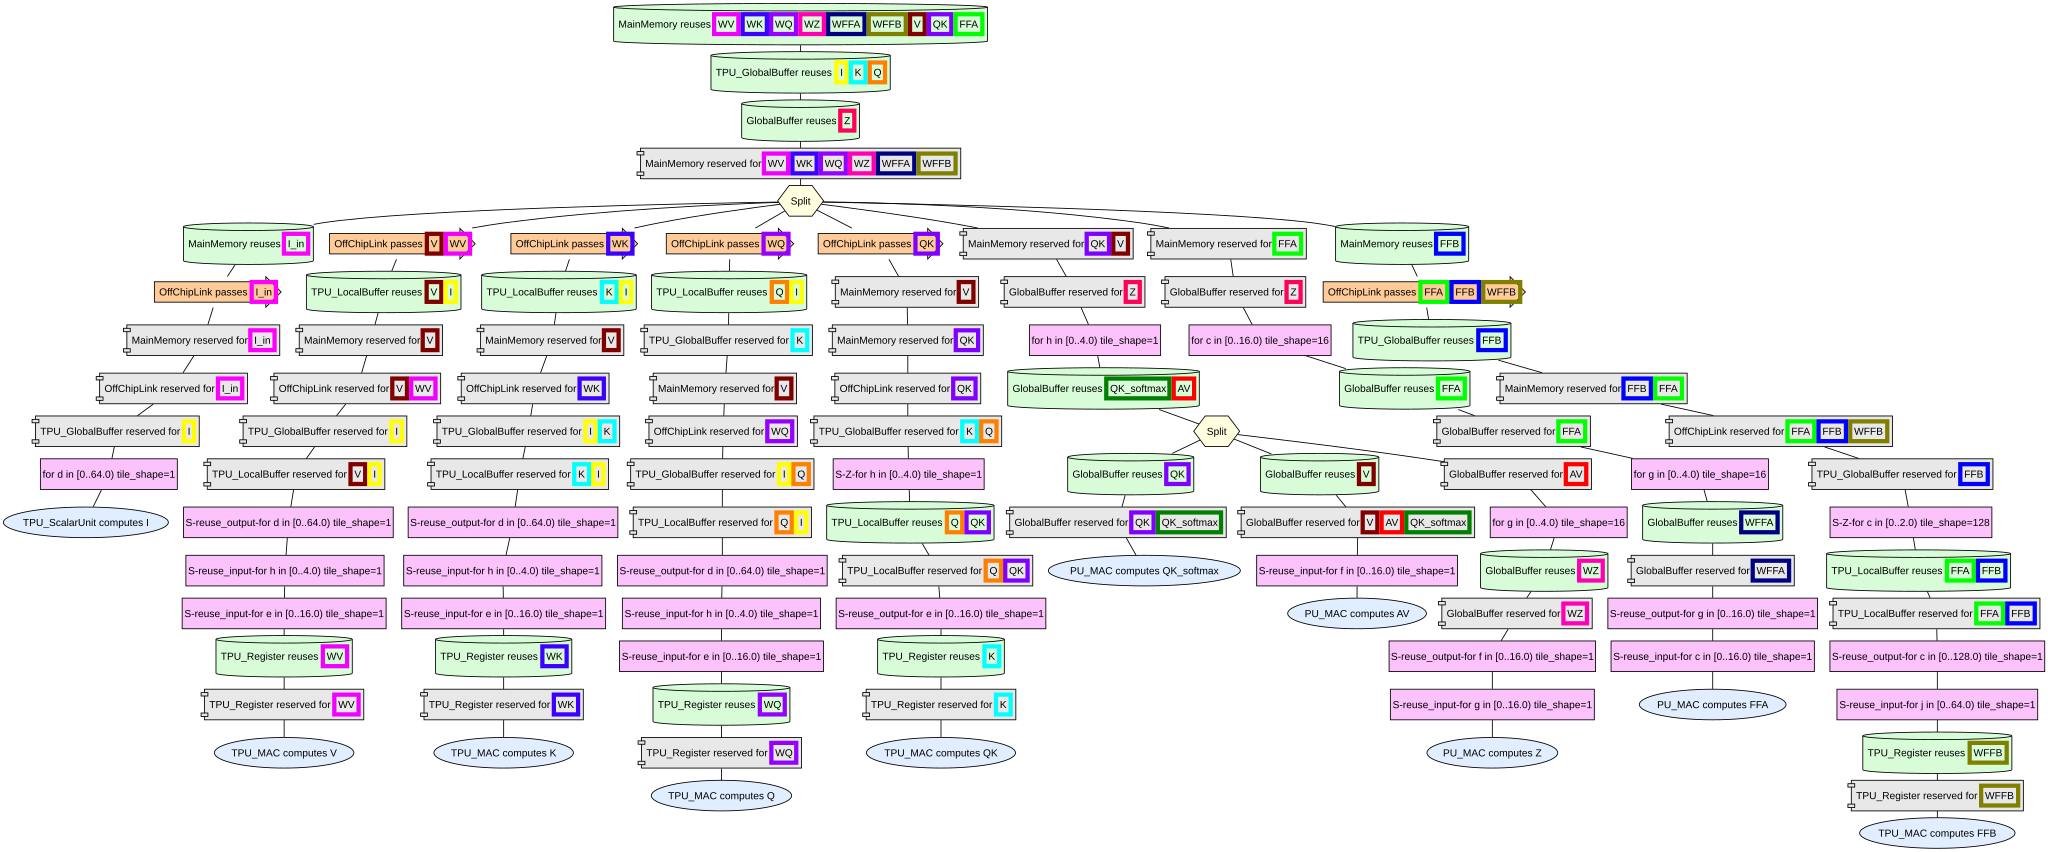

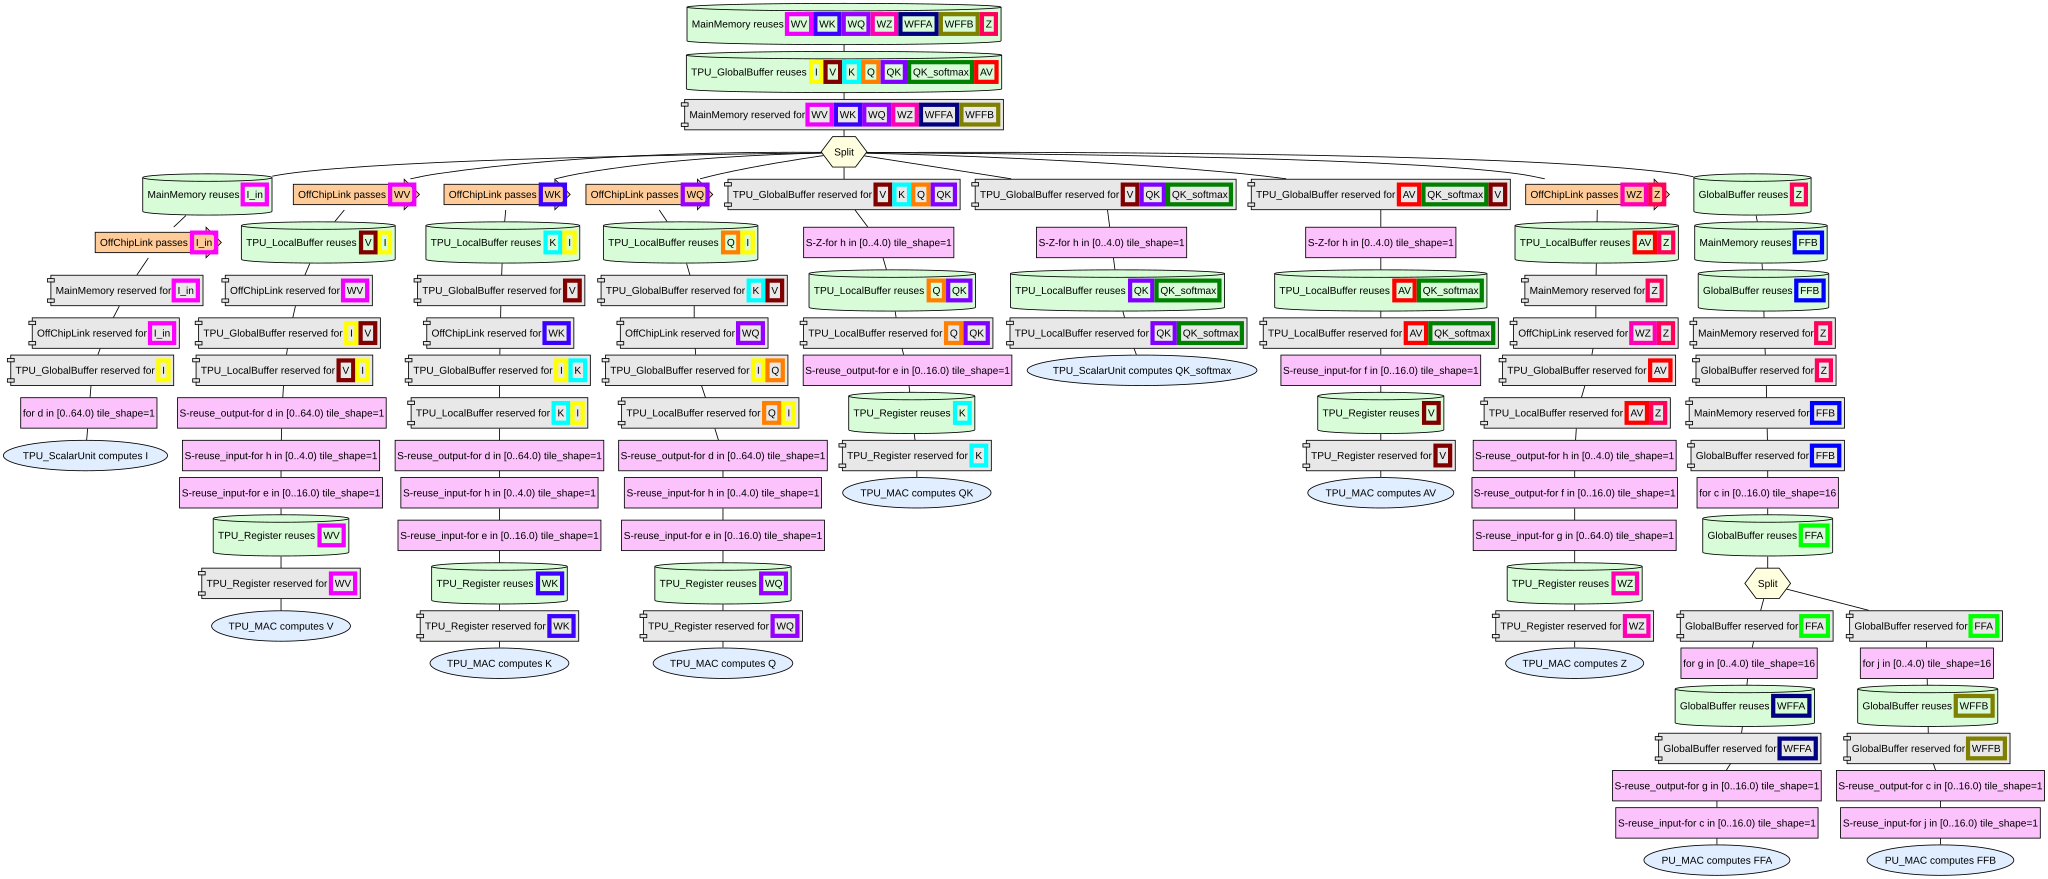

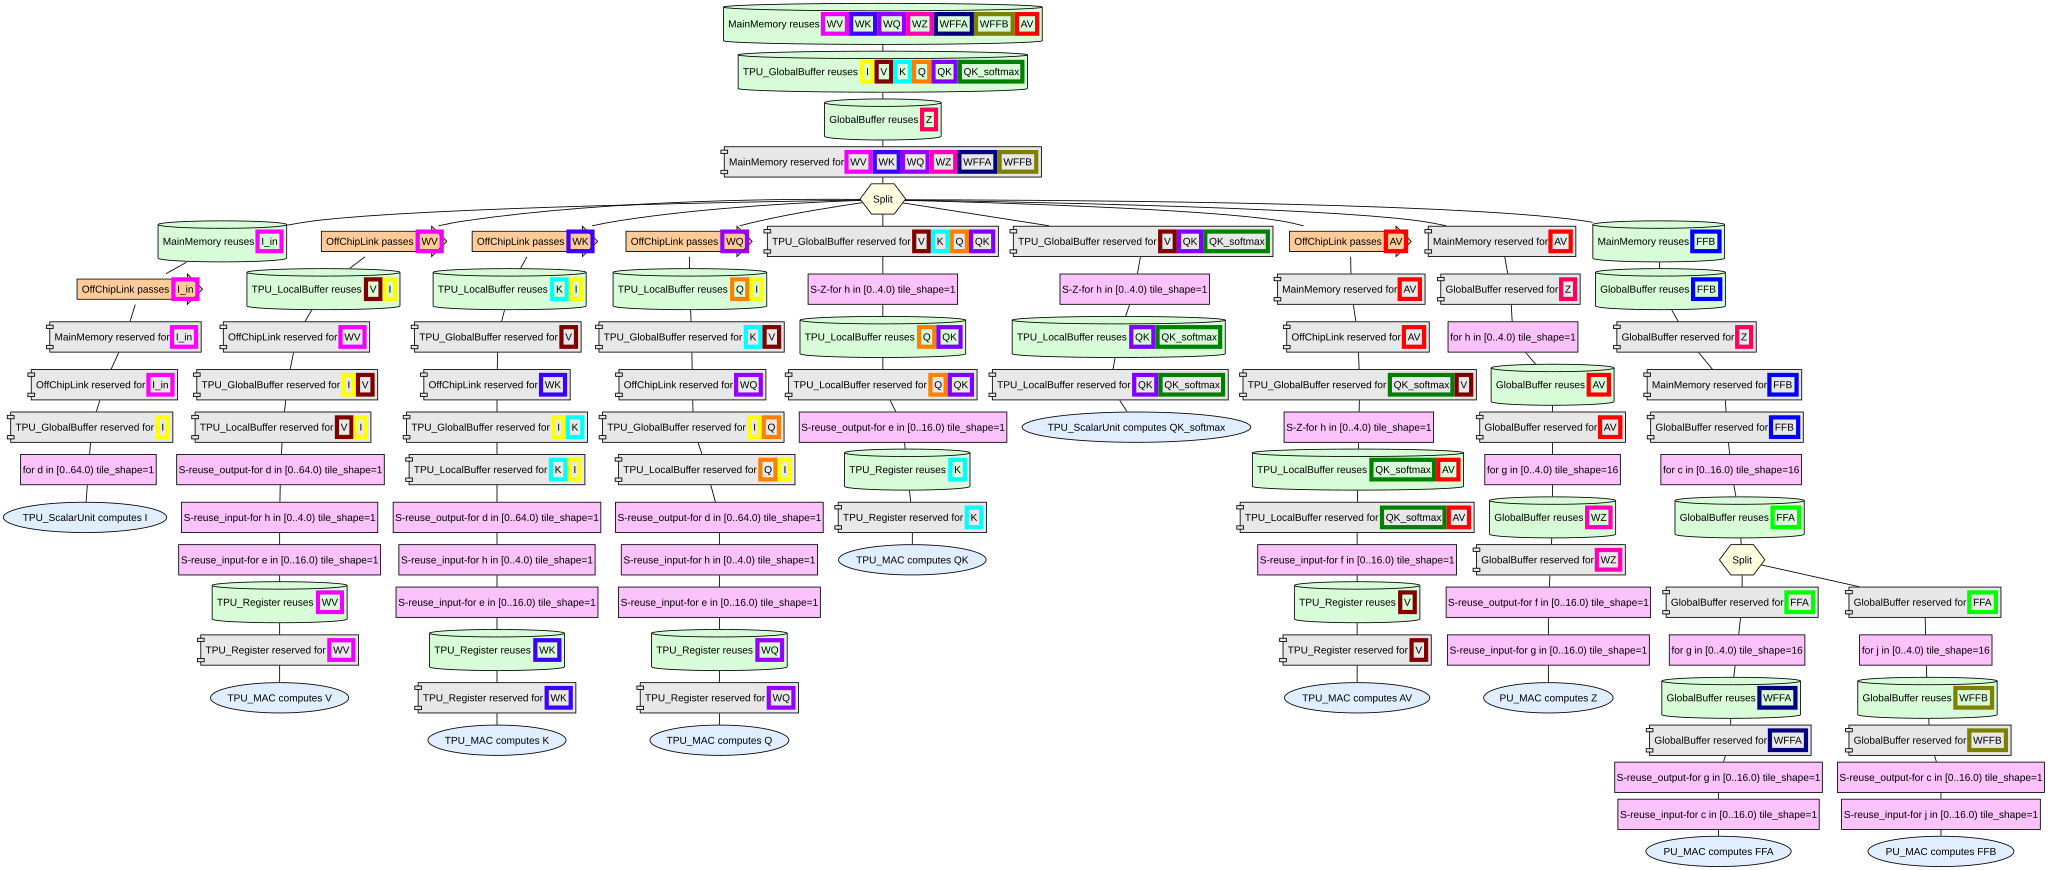

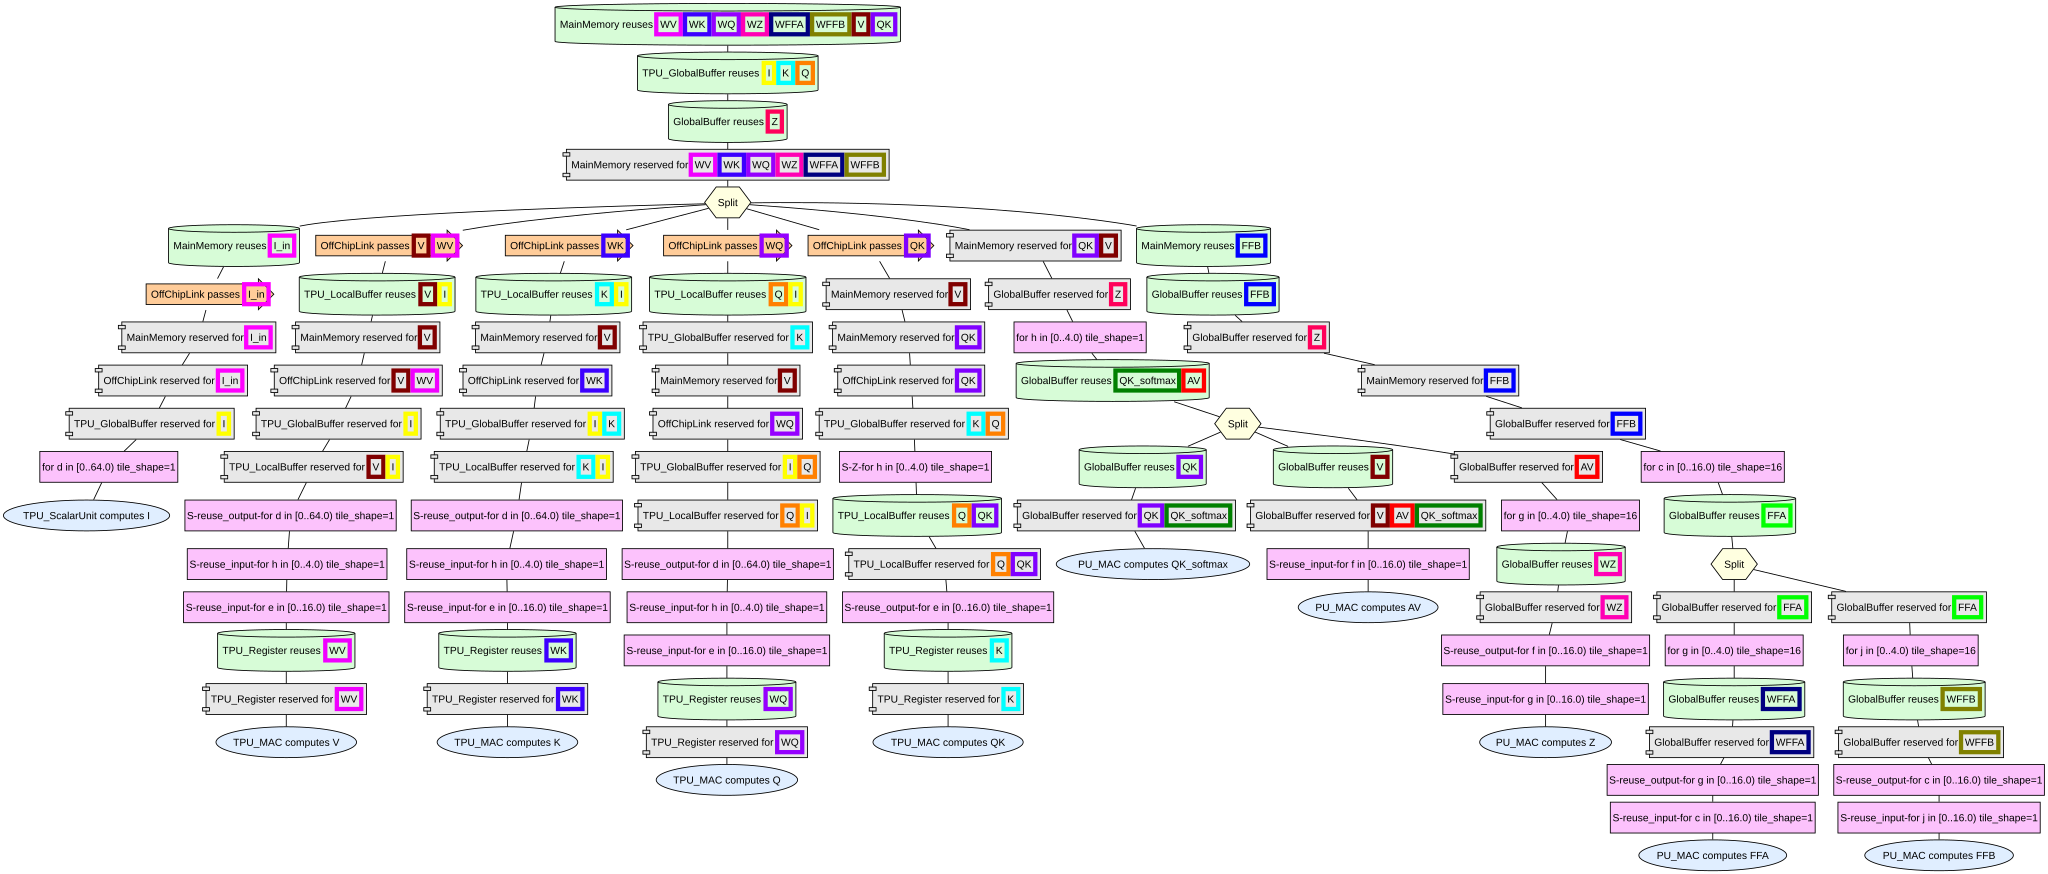

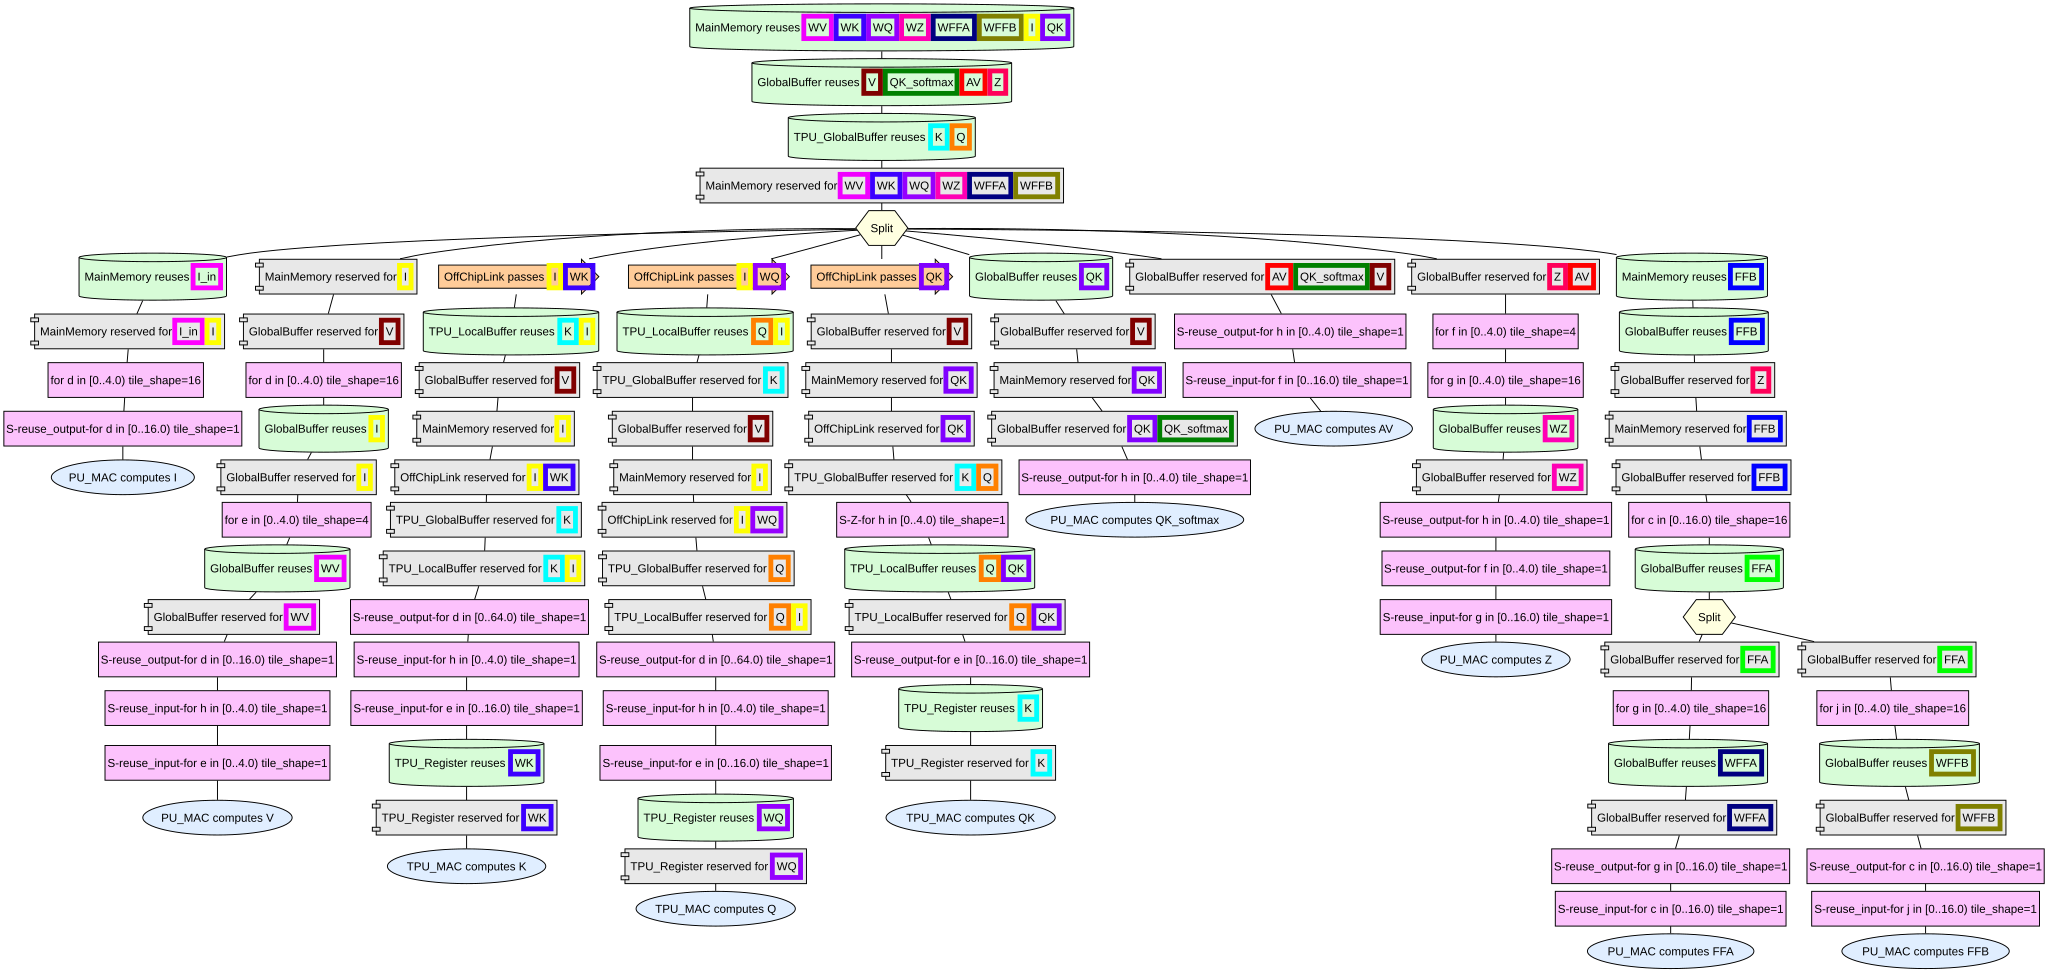

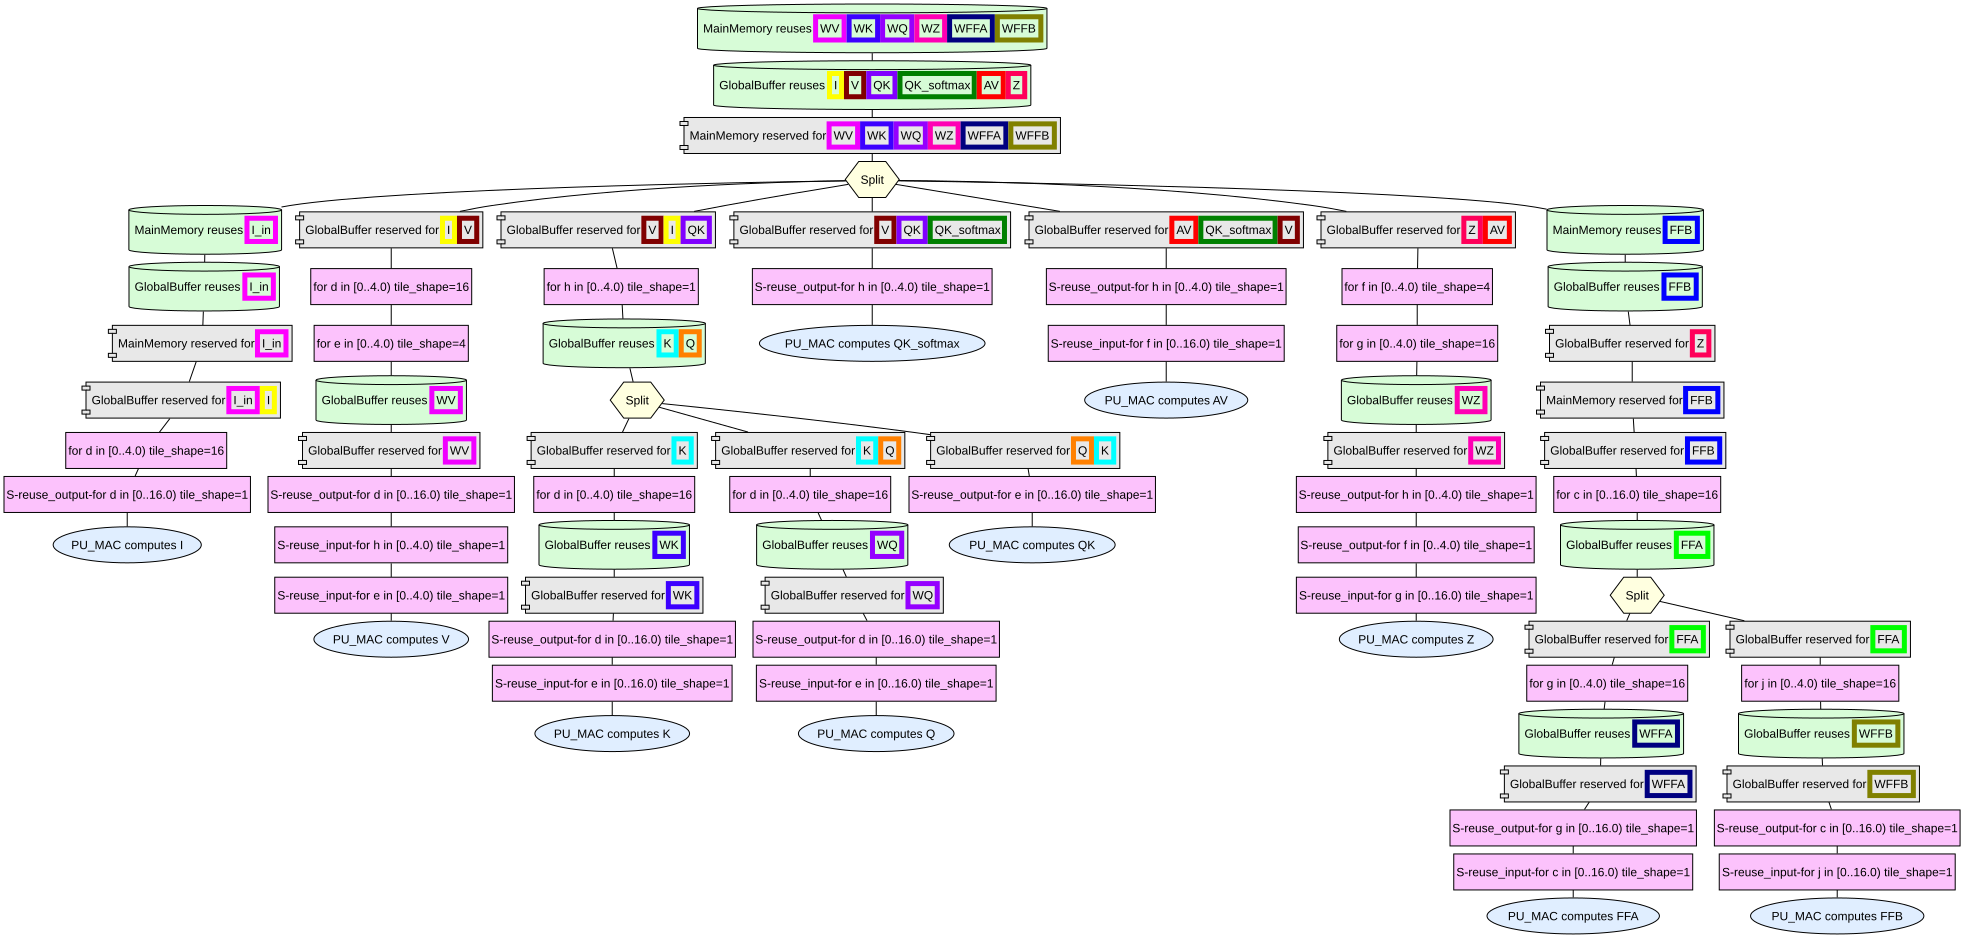

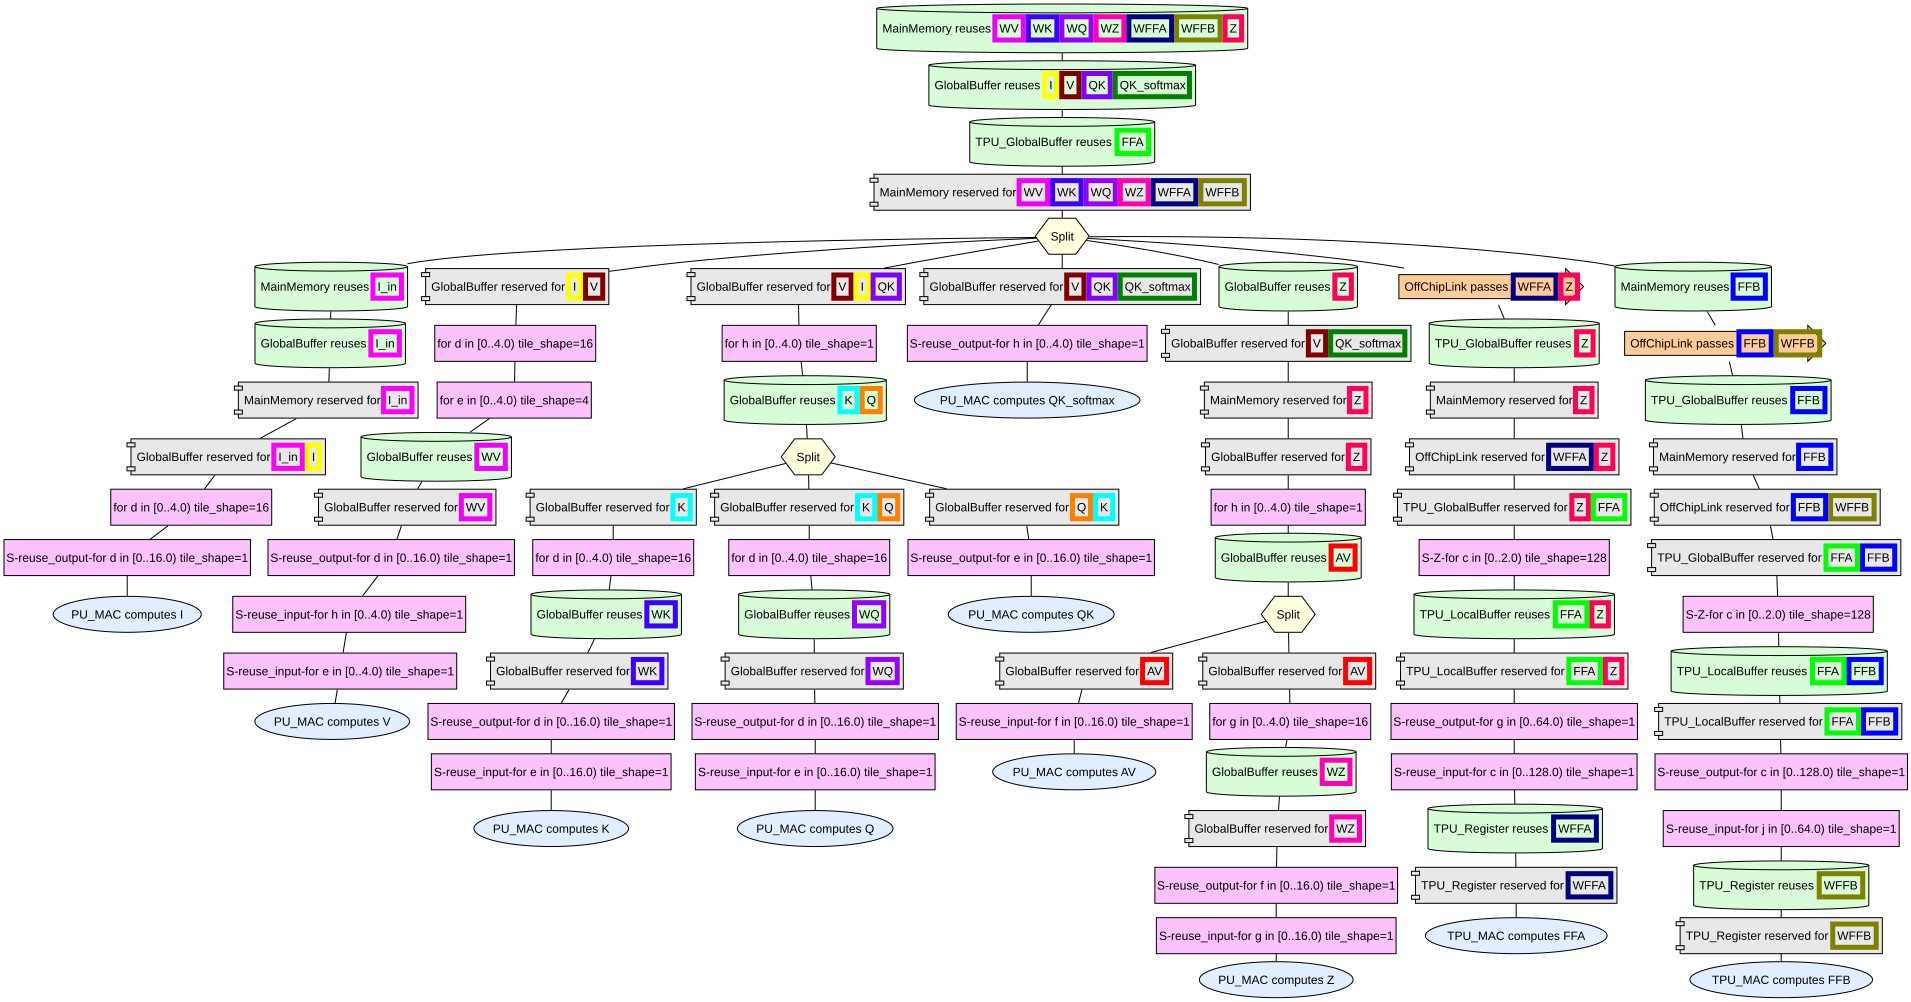

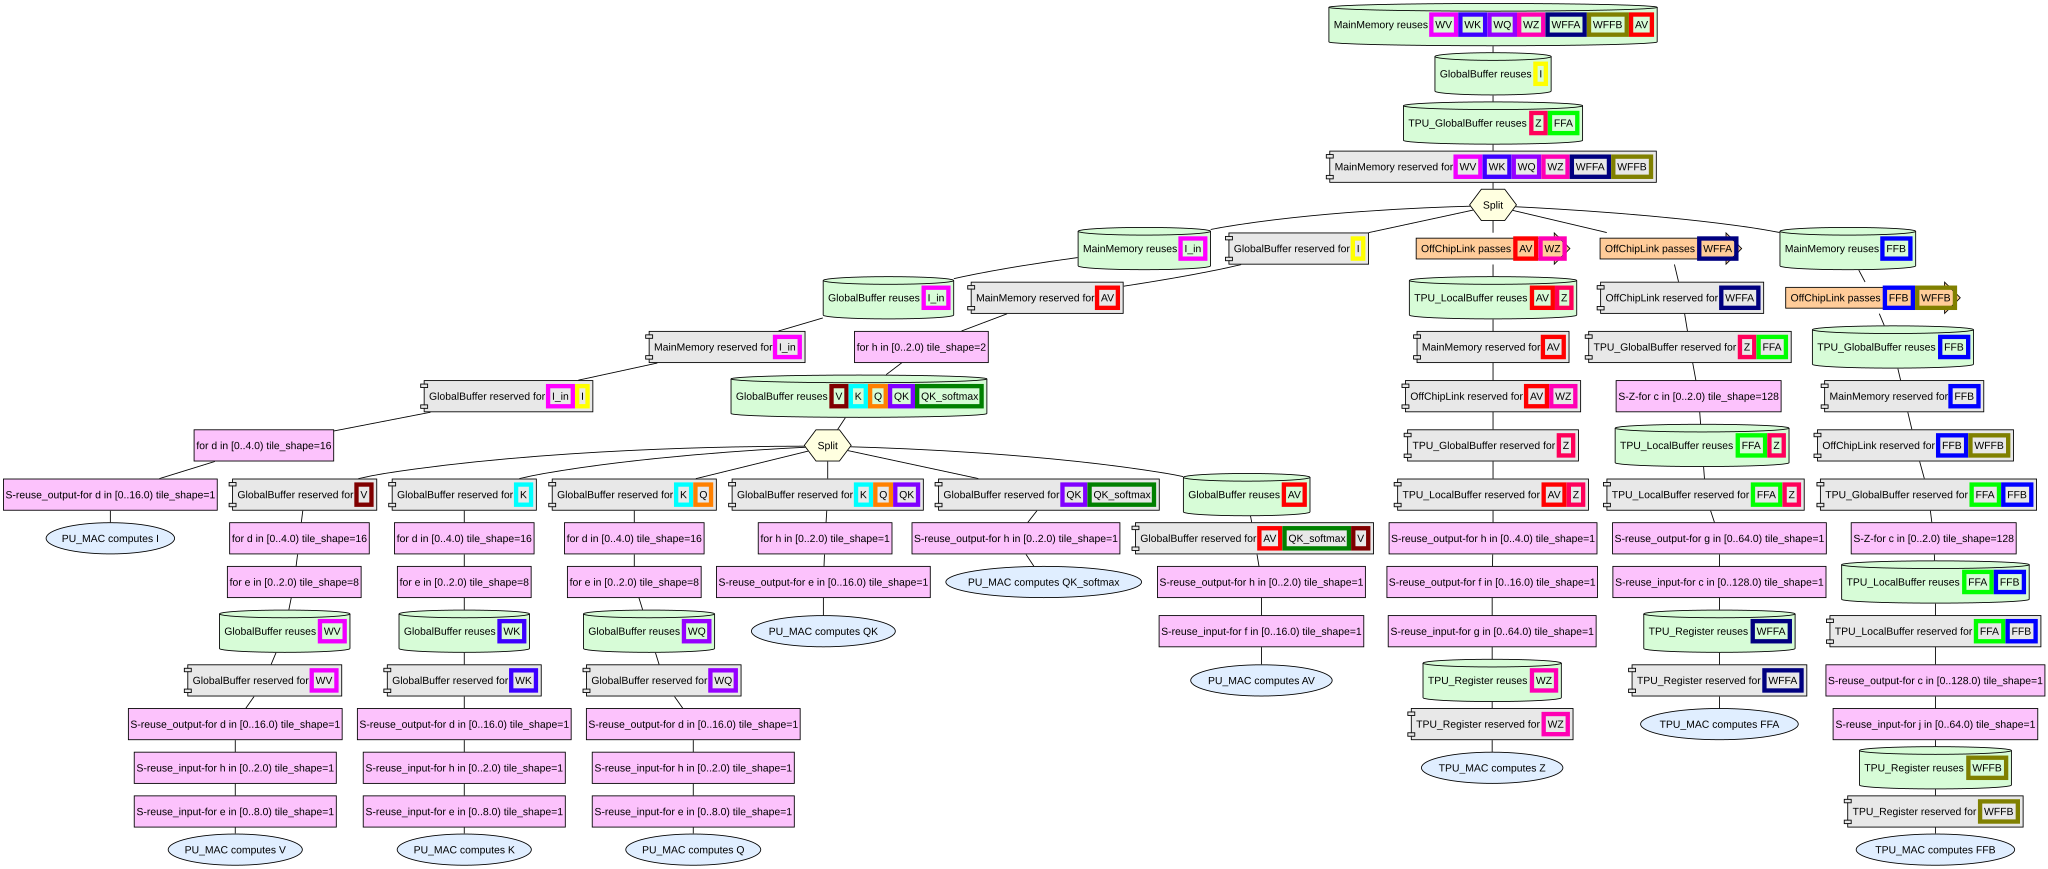

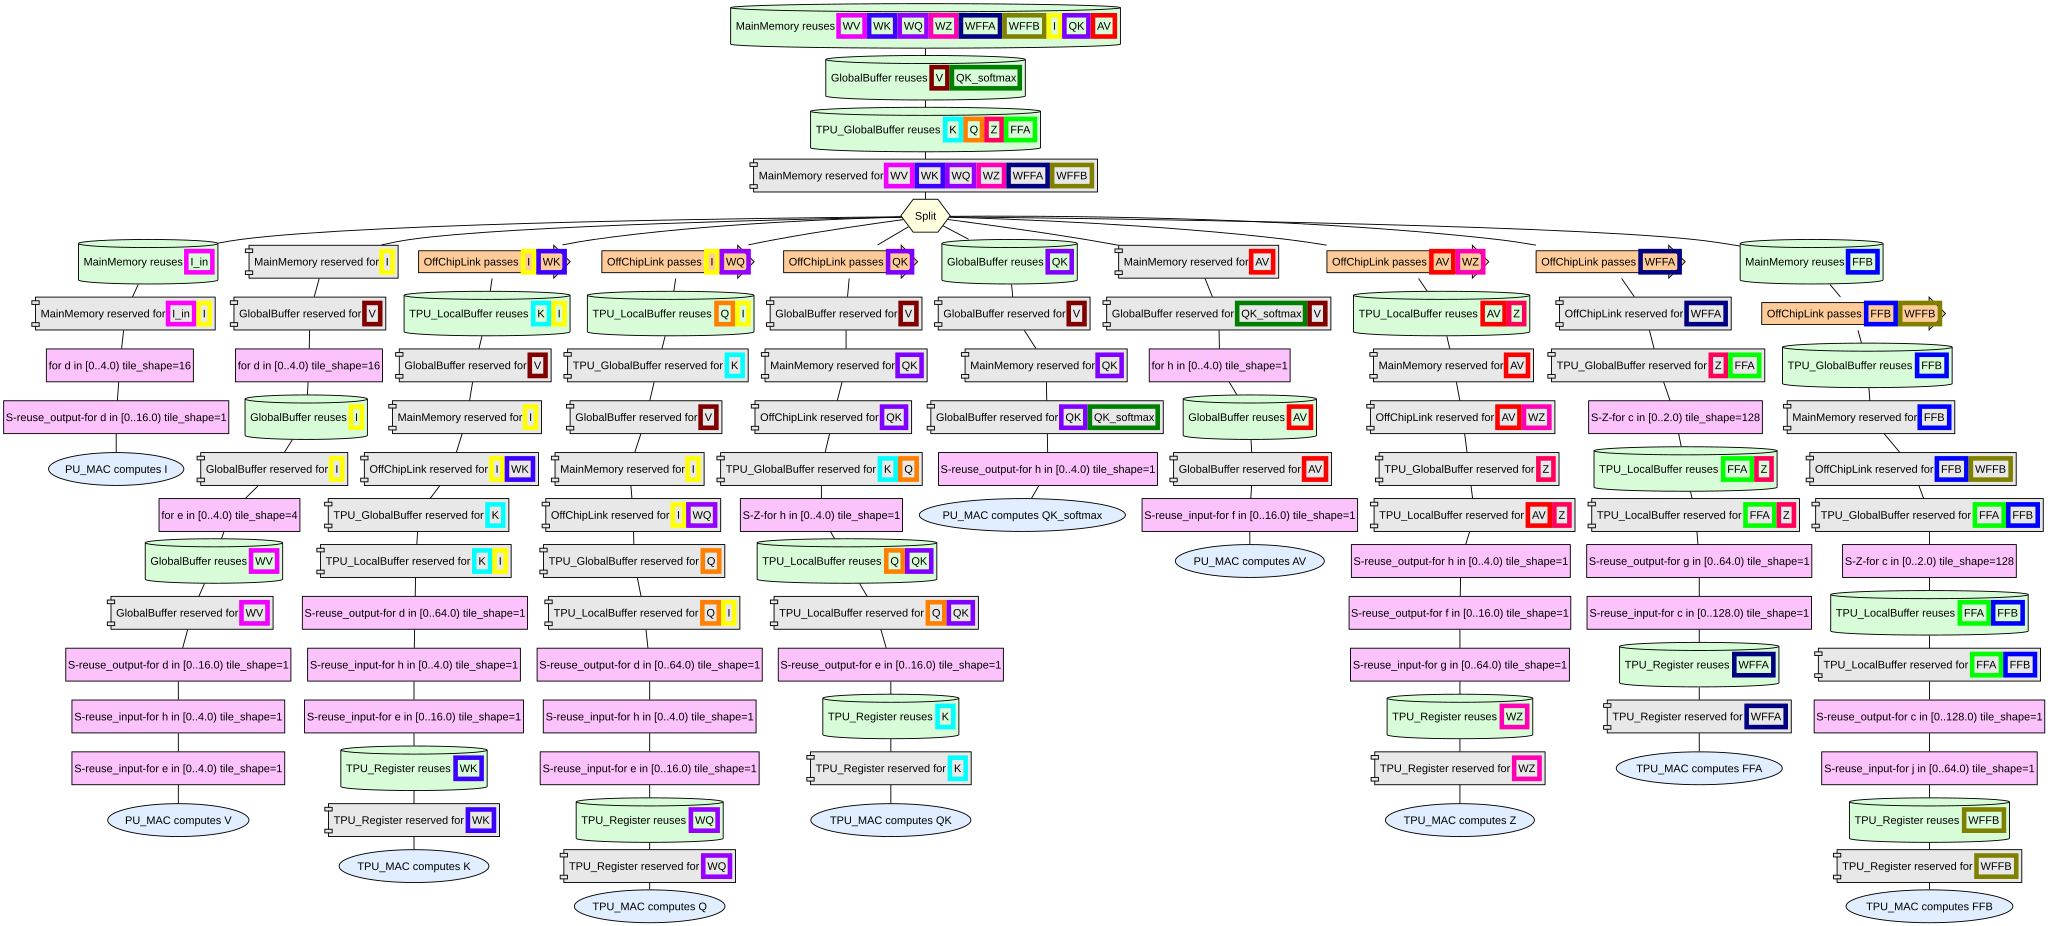

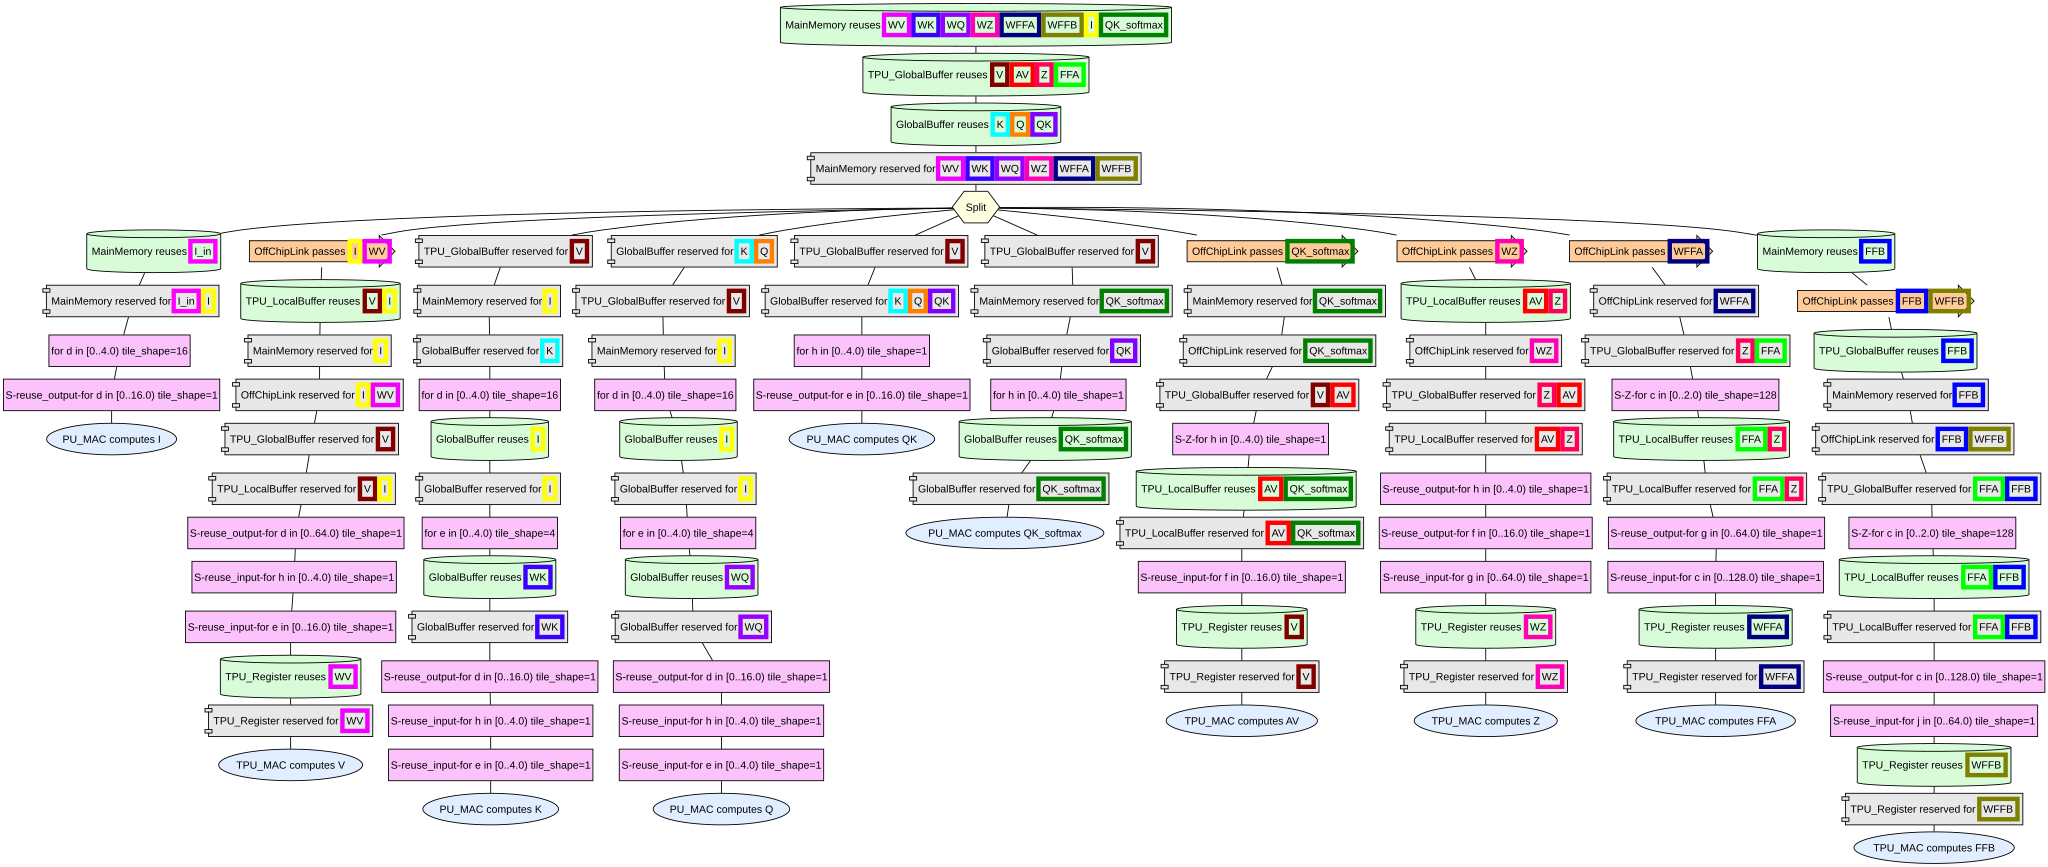

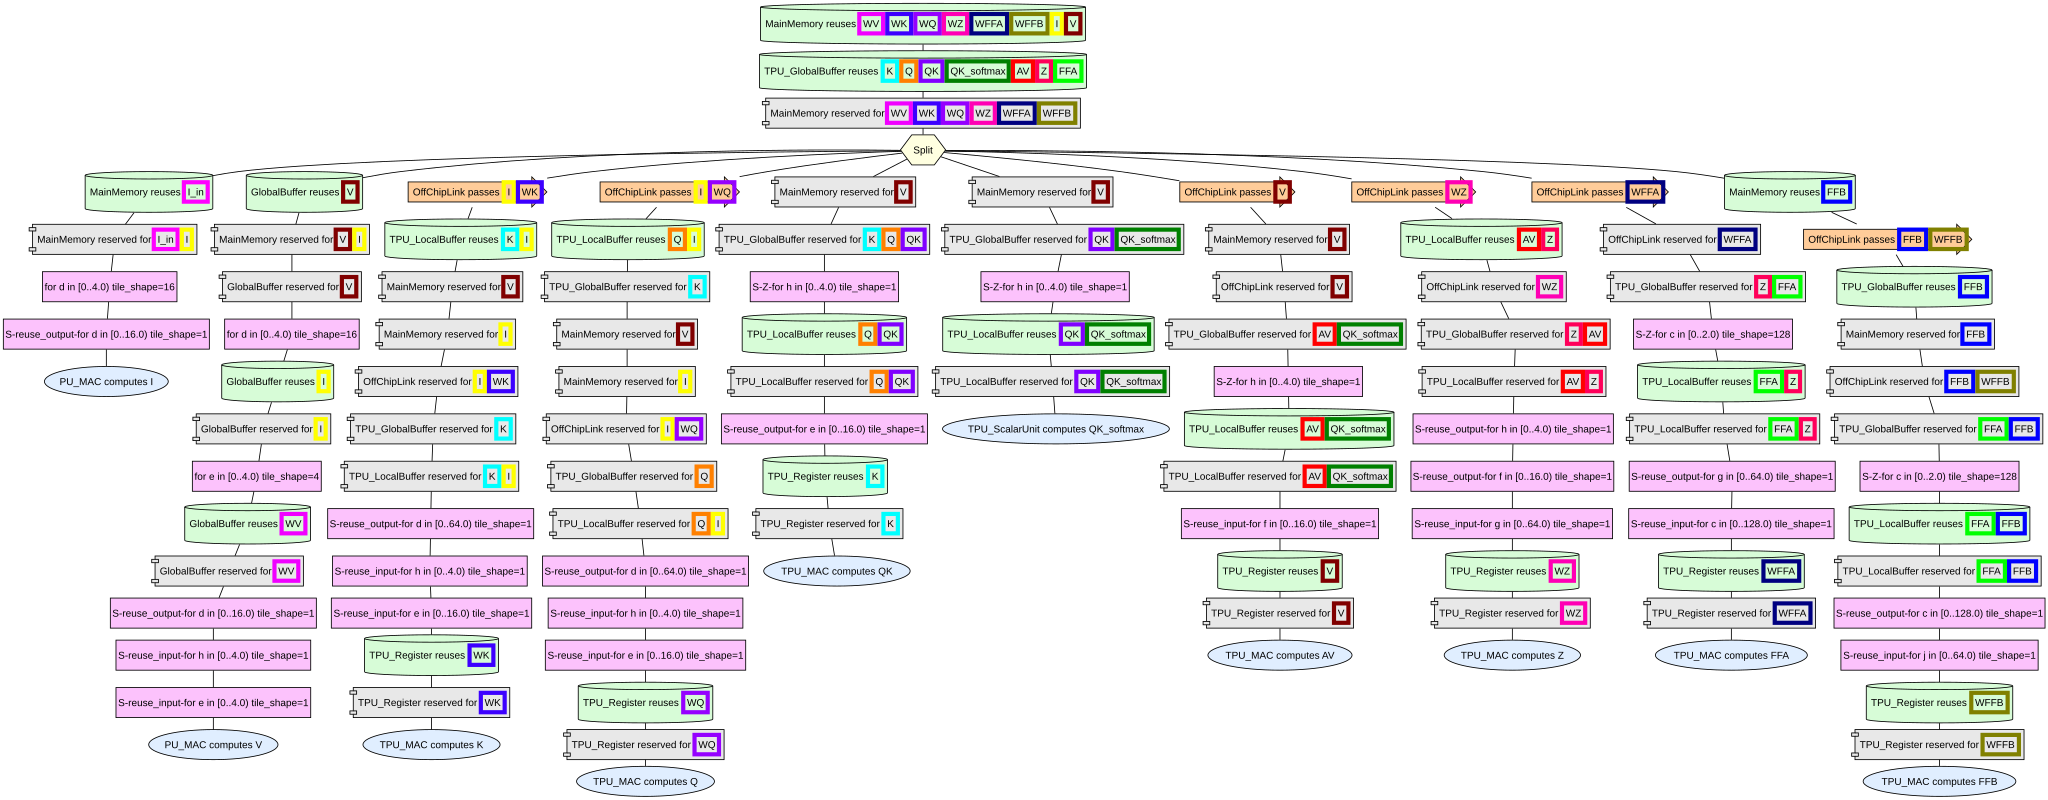

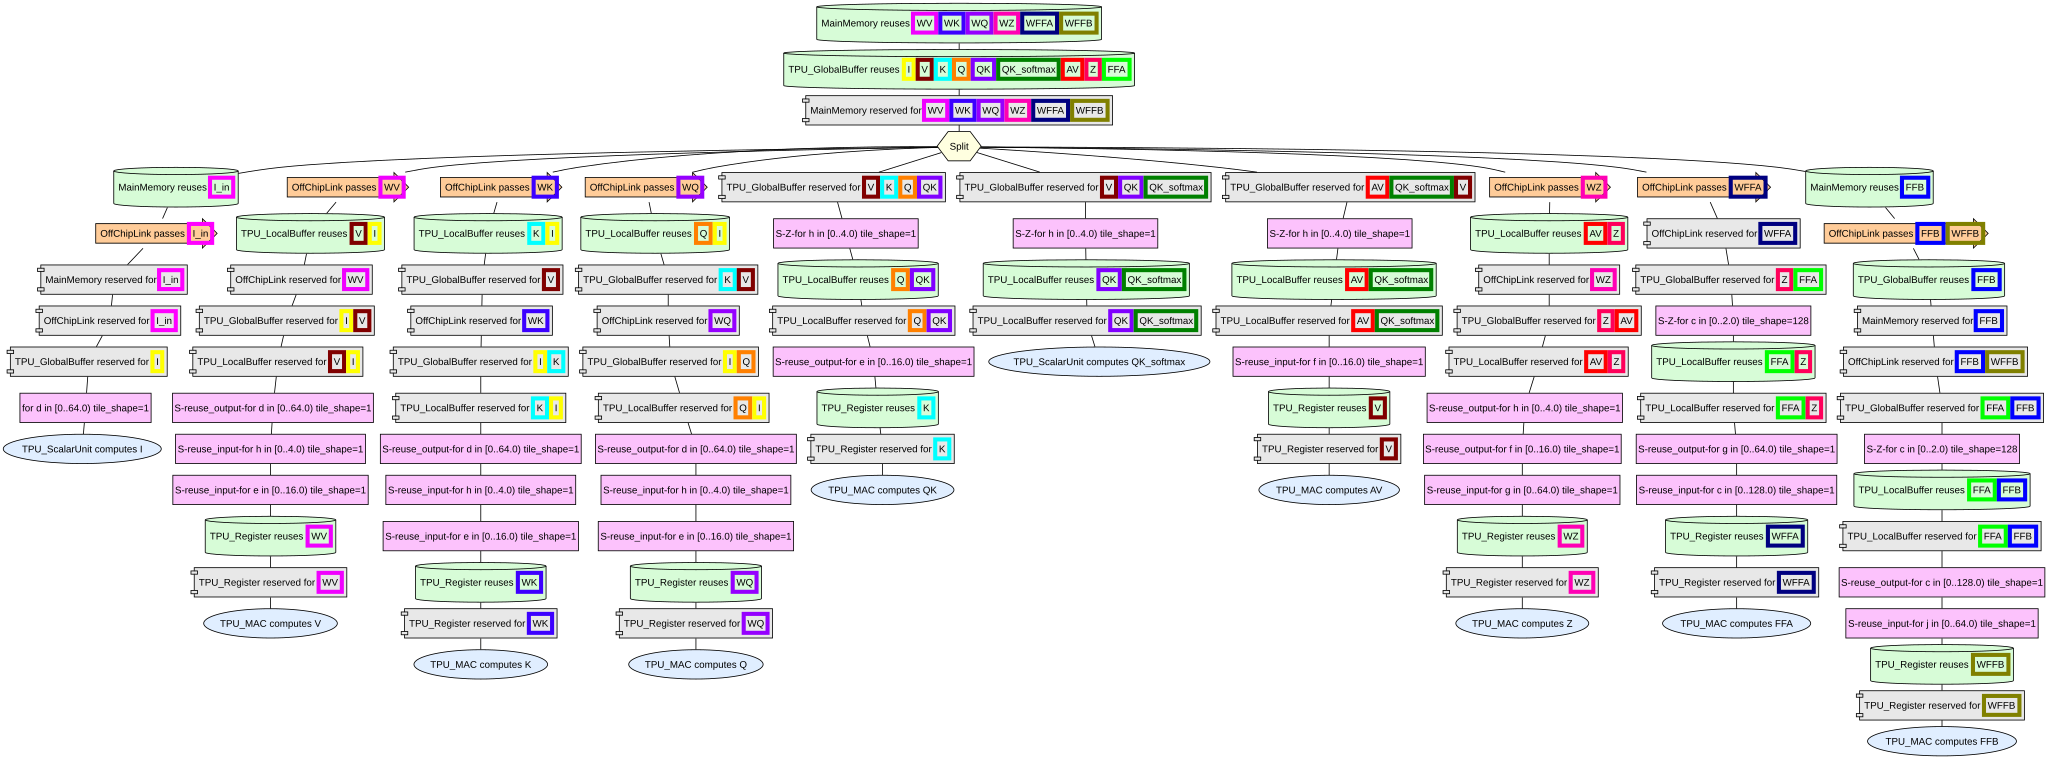

In [9]:

from IPython.display import display

for i in range(len(mapping)):
    display(mapping[i].render())

## Results

Helper to pick a single result when the mapper returns a Pareto set (list of
optimal trade-offs). We select the point with minimum latency.

### Per-Component Energy and Latency

This shows which hardware components dominate energy and latency. 

In [10]:
print(mapping.energy())

[5.763070853005714e-06, 5.758775316903058e-06, 5.765199749831688e-06, 5.781199749616187e-06, 5.776904213513531e-06, 5.789545493107169e-06, 5.805920661017428e-06, 5.685329302319201e-06, 5.664987542466485e-06, 5.648612374556226e-06, 5.654556694726316e-06, 5.652907910664512e-06, 5.615505287758374e-06]


EDP IDX: 6


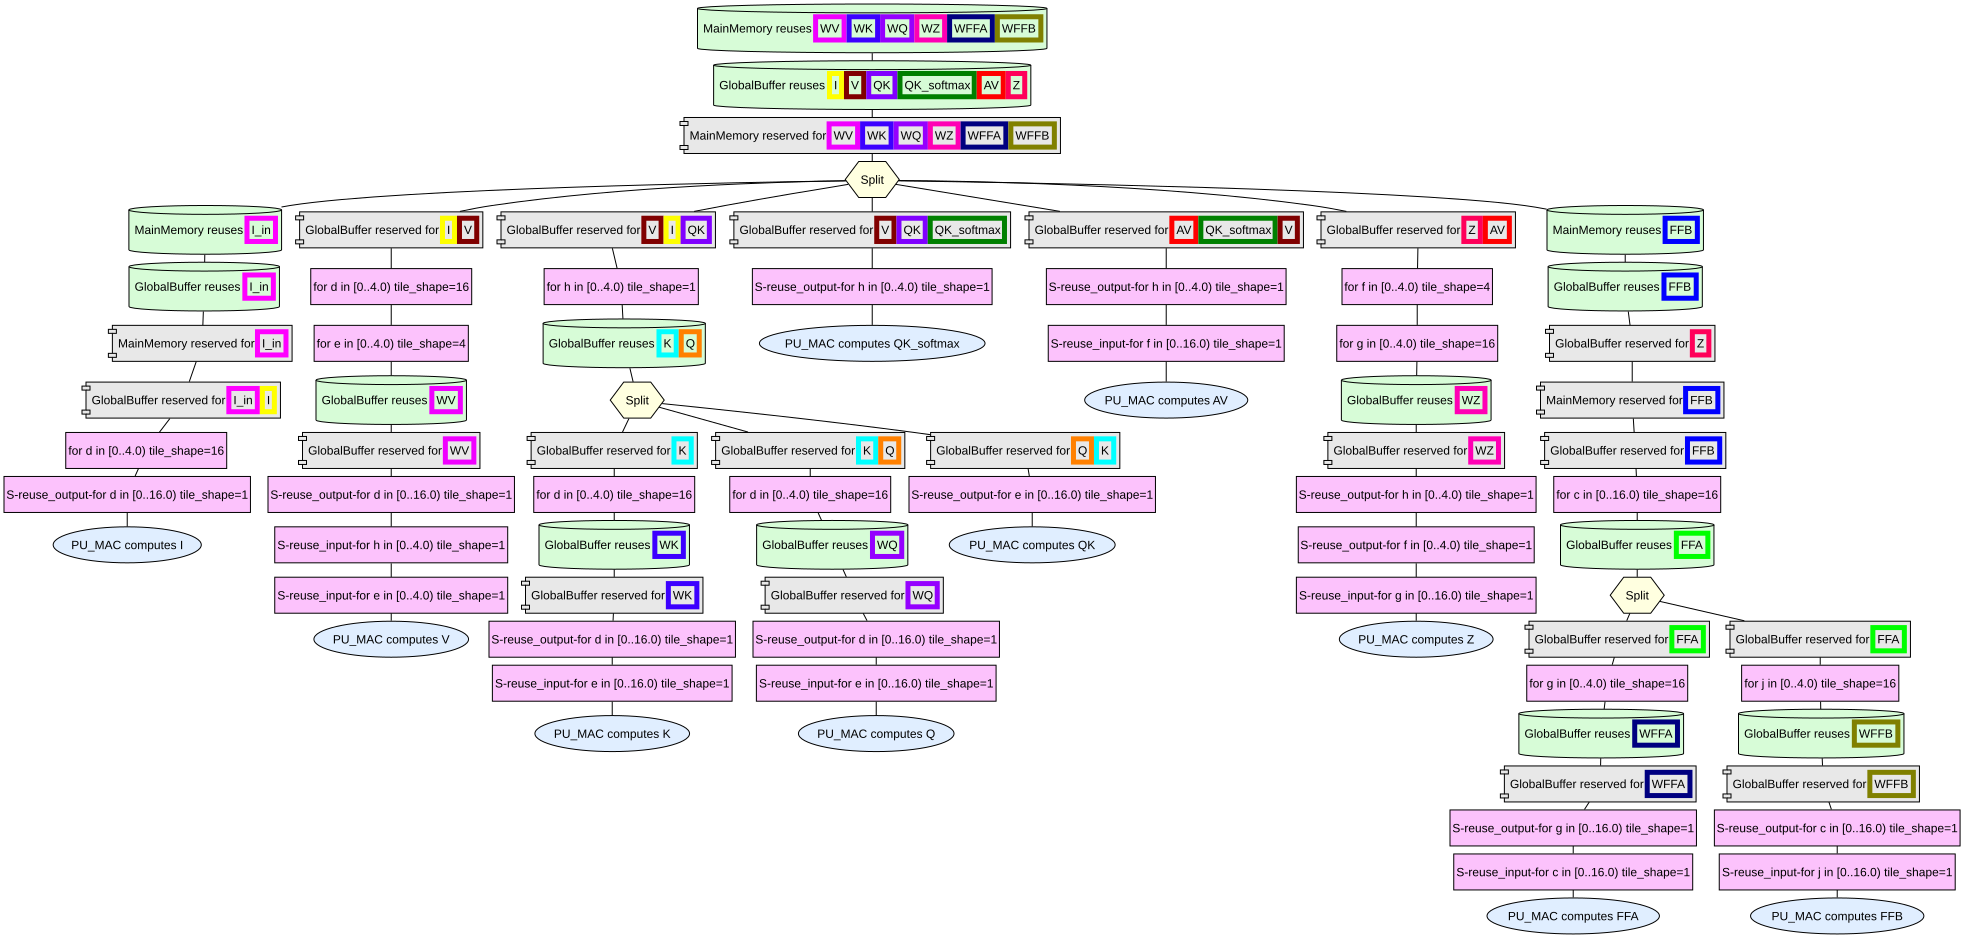

{'TPU_GlobalBuffer': np.float64(0.0), 'OffChipLink': np.float64(0.0), 'MainMemory': np.float64(5.543014278686087e-06), 'GlobalBuffer': np.float64(2.579779823313416e-07), 'TPU_LocalBuffer': np.float64(0.0), 'TPU_ScalarUnit': np.float64(0.0), 'TPU_Register': np.float64(0.0), 'TPU_MAC': np.float64(0.0), 'PU_MAC': np.float64(4.9284000000000005e-09)}
{'TPU_GlobalBuffer': np.float32(0.0), 'OffChipLink': np.float32(0.0), 'MainMemory': np.float64(1.6052117439435687e-07), 'TPU_ScalarUnit': np.float32(0.0), 'PU_MAC': np.float32(1.2625e-08), 'GlobalBuffer': np.float64(0.0), 'TPU_MAC': np.float32(0.0), 'TPU_LocalBuffer': np.float64(0.0), 'TPU_Register': np.float64(0.0)}


In [11]:
def pick(val, idx=None):
    """If val is a list (Pareto set), pick element at idx (default: 0)."""
    if isinstance(val, list):
        return val[idx if idx is not None else 0]
    return val


def best_energy_latency_product_idx(result):
    """Choose Pareto index minimizing energy * latency"""
    energies = result.energy()
    latencies = result.latency()
    
    idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
    print("EDP IDX:", idx)
    return idx
    # return None


SELECTED_IDX = best_energy_latency_product_idx(mapping)

tmapping = mapping[SELECTED_IDX]
display(tmapping.render())

energy_by_comp = tmapping.energy(per_component=True)
latency_by_comp = tmapping.latency(per_component=True)

print(energy_by_comp)
print(latency_by_comp)



### Per-Einsum Breakdown

Shows energy and latency for each operation, and which compute path was used.

In [12]:

tmapping_energy = tmapping.energy(per_einsum=True)
tmapping_latency = tmapping.latency(per_einsum=True)

# Determine which path each einsum uses by checking the mapping string
mapping_col = "Total<SEP>mapping"
has_mapping_col = mapping_col in mapping.data.columns


def detect_path(einsum_name, row_index: int):
    """Detect TPU vs AiM from the mapping string for a given einsum."""
    if has_mapping_col:
        row = mapping.data.iloc[min(row_index, len(mapping.data) - 1)]
        mapping_str = str(row.get(mapping_col, ""))
        ein_col = f"{einsum_name}<SEP>mapping"
        if ein_col in mapping.data.columns:
            mapping_str = str(row.get(ein_col, ""))
        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            return "TPU"
        if "PU_MAC" in mapping_str:
            return "AiM"
    return "?"


print(f"{'Einsum':<15} {'Path':<6} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)


tpu_einsums, aim_einsums = [], []

for ein in tmapping_energy:
    e = pick(tmapping_energy[ein], IDX)
    l = pick(tmapping_latency.get(ein, 0), IDX)
    path = detect_path(ein, IDX)
    if path == "TPU":
        tpu_einsums.append(ein)
    elif path == "AiM":
        aim_einsums.append(ein)
print(f"\nTPU einsums: {', '.join(tpu_einsums) or 'none'}")
print(f"AiM einsums: {', '.join(aim_einsums) or 'none'}")

Einsum          Path       Energy (J)    Latency (s)
-------------------------------------------------------


NameError: name 'IDX' is not defined

## Visualizations

Energy breakdown by component, stacked by einsum.

In [ ]:
from accelforge.plotting.mappings import plot_energy_breakdown

plot_energy_breakdown([tmapping], separate_by=["component"])

In [ ]:
plot_energy_breakdown([tmapping], separate_by=["component"], stack_by=["einsum"])

In [ ]:
plot_energy_breakdown([tmapping], separate_by=["component"], stack_by=["tensor"])

## Decode vs Prefill Comparison

During decode (M=1), operations are memory-bound and should favor AiM.
During prefill (M=128), operations become compute-bound and should favor the TPU.
We compare the two phases by re-mapping with different token counts.

In [ ]:
results_by_phase = {}

for phase, tokens in [("Decode (M=1)", 1), ("Prefill (M=128)", 128)]:
    phase_params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": tokens}
    phase_spec = af.Spec.from_yaml(
        HYBRID_ARCH, WORKLOAD, jinja_parse_data=phase_params
    )
    phase_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    phase_mapping = phase_spec.map_workload_to_arch()
    for i in range(len(phase_mapping)):
        display(phase_mapping[i].render())
    phase_idx = best_energy_latency_product_idx(phase_mapping)
    selected_phase_idx = 0 if phase_idx is None else phase_idx
    results_by_phase[phase] = {
        "mapping": phase_mapping,
        "selected_idx": selected_phase_idx,
        "energy": pick(phase_mapping.energy(), selected_phase_idx),
        "latency": pick(phase_mapping.latency(), selected_phase_idx),
    }
    print(
        f"{phase}: idx={selected_phase_idx}, "
        f"energy={results_by_phase[phase]['energy']:.4e} J, "
        f"latency={results_by_phase[phase]['latency']:.4e} s"
    )

In [ ]:
phase_mappings = [v["mapping"] for v in results_by_phase.values()]
phase_labels = list(results_by_phase.keys())

plot_energy_breakdown(
    phase_mappings,
    separate_by=["component"],
    stack_by=["einsum"],
    labels=phase_labels,
)

## Per-Einsum: TPU vs AiM  Comparison

To understand why the mapper picks one path over the other, we map each einsum
independently to a TPU-only architecture and an AiM-only architecture (both sharing
the same MainMemory). This lets us directly compare energy and latency per-einsum
on each path.

In [ ]:
params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS}
einsum_names = [e.name for e in spec.workload.einsums]

comparison = {}

for name in einsum_names:
    row = {}
    for label, arch_path in [("TPU",'/Users/erik/Downloads/accelforge/examples/arches/tpu_only.yaml' ), ("AiM", '/Users/erik/Downloads/accelforge/examples/arches/aim_only.yaml')]:
        try:
            s = af.Spec.from_yaml(arch_path, str(WORKLOAD), jinja_parse_data=params)
            s.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
            r = s.map_workload_to_arch(einsum_names=[name], print_progress=False)
            # Pick min-latency Pareto point
            lat = r.latency()
            if isinstance(lat, list):
                idx = min(range(len(lat)), key=lambda i: lat[i])
                row[label] = {"energy": lat[idx], "latency": lat[idx]}
                # Fix: get energy at same index
                eng = r.energy()
                row[label] = {"energy": eng[idx], "latency": lat[idx]}
            else:
                row[label] = {"energy": r.energy(), "latency": r.latency()}
        except Exception as e:
            row[label] = {"energy": float("nan"), "latency": float("nan"), "error": str(e)}
    comparison[name] = row
    
    tpu_lat = row["TPU"]["latency"]
    aim_lat = row["AiM"]["latency"]
    winner = "TPU" if tpu_lat <= aim_lat else "AiM"
    print(f"{name:<15} TPU lat={tpu_lat:.3e}  AiM lat={aim_lat:.3e}  -> {winner}")

### Summary Table

In [ ]:
import math

header = f"{'Einsum':<15} {'TPU Energy':>12} {'TPU Latency':>12} {'AiM Energy':>12} {'AiM Latency':>12} {'Lat Winner':>10} {'Lat Ratio':>10}"
print(header)
print("-" * len(header))

for name, row in comparison.items():
    te = row["TPU"]["energy"]
    tl = row["TPU"]["latency"]
    ae = row["AiM"]["energy"]
    al = row["AiM"]["latency"]
    
    if math.isnan(tl) or math.isnan(al):
        winner = "error"
        ratio = "N/A"
    elif tl <= al:
        winner = "TPU"
        ratio = f"{al/tl:.2f}x"
    else:
        winner = "AiM"
        ratio = f"{tl/al:.2f}x"
    
    print(f"{name:<15} {te:>12.3e} {tl:>12.3e} {ae:>12.3e} {al:>12.3e} {winner:>10} {ratio:>10}")

### Latency and Energy Comparison Charts

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

names = list(comparison.keys())
tpu_latencies = [comparison[n]["TPU"]["latency"] for n in names]
aim_latencies = [comparison[n]["AiM"]["latency"] for n in names]
tpu_energies = [comparison[n]["TPU"]["energy"] for n in names]
aim_energies = [comparison[n]["AiM"]["energy"] for n in names]

x = np.arange(len(names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Latency comparison
ax1.bar(x - width/2, tpu_latencies, width, label="TPU", color="steelblue")
ax1.bar(x + width/2, aim_latencies, width, label="AiM", color="coral")
ax1.set_ylabel("Latency (s)")
ax1.set_title("Per-Einsum Latency: TPU vs AiM")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha="right")
ax1.legend()
ax1.set_yscale("log")

# Energy comparison
ax2.bar(x - width/2, tpu_energies, width, label="TPU", color="steelblue")
ax2.bar(x + width/2, aim_energies, width, label="AiM", color="coral")
ax2.set_ylabel("Energy (J)")
ax2.set_title("Per-Einsum Energy: TPU vs AiM")
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=45, ha="right")
ax2.legend()
ax2.set_yscale("log")

plt.tight_layout()
plt.show()